In [1]:
from pathlib import Path
import math,random,os,sys, importlib, time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde

import torch
from torch.utils.data import DataLoader
from scipy import stats

# Repo paths
ROOT = Path.cwd().resolve().parents[0]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Local modules
import data.sample_x as sample_x_mod; importlib.reload(sample_x_mod)
import data.solve_ode as solve_ode_mod; importlib.reload(solve_ode_mod)
import data.utils as utils_mod; importlib.reload(utils_mod)

from data.sample_x import sample_x
from data.solve_ode import SpringParams, simulate_spring
from data.utils import plot_traj, check_safety, plot_x_safety_map, plot_mu_safety_map, compute_mu_safety_map
from data.datasets import SpringDataset, make_sequence_pairs
from train.models import build_cond_gru_model, EncoderOnly
from train.training import (
    train_eval_epoch,
    train_eval_epoch_enc_only,
)
from train.losses import mmd2_unif
from hypo_test.stats_tests import chisq_uniform_1d

# Global config
class Cfg:
    seed = 1
    n_samples = 5000
    T = 10.0
    dt = 0.05
    stride = 1
    dist_mean = np.array([0., 0.])
    dist_cov = np.diag([1., 1.])
    batch_train = 1024
    batch_val = 1024
    epochs = 100
    lr = 3e-3
    weight_decay = 1e-5
    lr_enc = 3e-3
    weight_decay_enc = 0
    lambda_mmd = 1e-2
    d_x = 2
    d_o = 1
    d_v = 1
    d_h = 128
    hidden_enc = 512
    hidden_dec = 128
    B_bins = 20  # chi-square bins

# Reproducibility
torch.manual_seed(Cfg.seed)
np.random.seed(Cfg.seed)
random.seed(Cfg.seed)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)


/Users/mzheng/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


device: mps


In [2]:
# 1. train two models: proposed model and encoder only model
# 2. visualize their latent variable uniformity
# 3. perturb data, change mean and variance, and check how latent shfits, say divergence between shifted latent to uniformity


In [3]:
z_0 = np.array([0.0, 0.0]) # baselien config
params = SpringParams(mass=1.0, damping=1.0, stiffness=2.0) # paramters theta

X = sample_x(
    n_samples=Cfg.n_samples,
    dist_type="gaussian",
    params={"mean": Cfg.dist_mean, "cov": Cfg.dist_cov},
    seed=Cfg.seed,
)

traj = simulate_spring(params, t_final=Cfg.T, dt=Cfg.dt, X=X, forcing_type="sin", config=z_0)
s = traj["s"]                           # (N, T_full)
assert X.shape[0] == s.shape[0]

o_hist,o_next = make_sequence_pairs( s=s,stride=Cfg.stride)
x_np   = X.astype(np.float32)

print("Shapes -> X:", x_np.shape, "trajectory shape:", s.shape)

N = x_np.shape[0]
perm = np.random.RandomState(Cfg.seed).permutation(N)
n_train = int(0.8 * N)
tr_idx, va_idx = perm[:n_train], perm[n_train:]

train_ds = SpringDataset(x_np[tr_idx], o_hist[tr_idx], o_next[tr_idx])
val_ds   = SpringDataset(x_np[va_idx], o_hist[va_idx], o_next[va_idx])

train_loader = DataLoader(train_ds, batch_size=Cfg.batch_train, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=Cfg.batch_val, shuffle=False)

# print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")



Shapes -> X: (5000, 2) trajectory shape: (5000, 201)


In [ ]:
import copy

# Divergence configuration
from train.losses import mmd2_unif, energy_distance_unif

div_fn = mmd2_unif
# Stable, low-variance settings; override as needed.
div_kwargs = {"sigmas": None, "low_discrepancy": True}

model = build_cond_gru_model(
    d_x=Cfg.d_x,
    d_o=Cfg.d_o,
    d_v=Cfg.d_v,
    d_h=Cfg.d_h,
    enc_layers=2,
    dec_layers=1,
    hidden_enc=Cfg.hidden_enc,
    hidden_dec=Cfg.hidden_dec,
    output_activation="sigmoid",
    dropout_rnn=0.1
).to(device)

# Encoder-only variant for pure latent uniform divergence regularization.
model_enc = EncoderOnly(copy.deepcopy(model.enc)).to(device)

opt = torch.optim.Adam(model.parameters(), lr=Cfg.lr, weight_decay=Cfg.weight_decay)
opt_enc = torch.optim.Adam(model_enc.parameters(), lr=Cfg.lr_enc, weight_decay=Cfg.weight_decay_enc)

Cfg.epochs = 100
history = []
best_val_mmd = float("inf")
best_state = None
use_val = val_loader is not None

for epoch in range(1, Cfg.epochs + 1):
    tr_loss, val_rec, val_div = train_eval_epoch(
        model=model,
        train_loader=train_loader,
        optimizer=opt,
        lambda_mmd=Cfg.lambda_mmd,
        device=device,
        val_loader=val_loader if use_val else None,
        divergence_fn=div_fn,
        divergence_kwargs=div_kwargs,
    )

    tr_div_enc, val_div_enc = train_eval_epoch_enc_only(
        model_enc=model_enc,
        train_loader=train_loader,
        optimizer=opt_enc,
        lambda_mmd=Cfg.lambda_mmd,
        device=device,
        val_loader=val_loader if use_val else None,
        divergence_fn=div_fn,
        divergence_kwargs=div_kwargs,
    )

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "val_recon": val_rec,
        "val_divergence": val_div,
        "train_div (enc-only)": tr_div_enc,
        "val_divergence (enc-only)": val_div_enc,
    })

    if use_val and val_div is not None and val_div < best_val_mmd:
        best_val_mmd = val_div
        best_state = model.state_dict()

    if epoch % 10 == 0 or epoch == 1:
        msg = f"[{epoch:02d}] train-loss={tr_loss:.6f}"
        if use_val:
            msg += (f"  val-recon={val_rec:.6f}  val-divergence={val_div:.6f}  "
                    f"  train-divergence (enc)={tr_div_enc:.6f} val-divergence (enc)={val_div_enc:.6f}")
        print(msg)

if use_val and best_state is not None:
    model.load_state_dict(best_state)
pd.DataFrame(history).tail()


[01] train-loss=0.127414  val-recon=0.092741  val-divergence=0.038936    train-divergence (enc)=0.217149 val-divergence (enc)=0.039797
[10] train-loss=0.002899  val-recon=0.003207  val-divergence=0.006998    train-divergence (enc)=0.006359 val-divergence (enc)=0.003918
[20] train-loss=0.000264  val-recon=0.000257  val-divergence=0.000178    train-divergence (enc)=0.000812 val-divergence (enc)=0.001453
[30] train-loss=0.000090  val-recon=0.000084  val-divergence=0.000140    train-divergence (enc)=0.001935 val-divergence (enc)=-0.000192
[40] train-loss=0.000055  val-recon=0.000124  val-divergence=0.000098    train-divergence (enc)=0.000137 val-divergence (enc)=0.000512
[50] train-loss=0.000057  val-recon=0.000044  val-divergence=0.000120    train-divergence (enc)=0.000048 val-divergence (enc)=0.000136
[60] train-loss=0.000169  val-recon=0.000050  val-divergence=0.000106    train-divergence (enc)=0.000255 val-divergence (enc)=0.000724
[70] train-loss=0.000030  val-recon=0.000027  val-dive

,epoch,train_loss,val_recon,val_divergence,train_div (enc-only),val_divergence (enc-only)
95,96,0.000114,0.000041,0.000373,-0.000357,-0.000032
96,97,0.000064,0.000081,0.000727,-0.000199,0.000138
97,98,0.000049,0.000077,0.000799,0.000230,0.000482
98,99,0.000046,0.000056,0.000395,0.001183,0.001372
99,100,0.000042,0.000031,0.000334,0.000948,0.000444


In [6]:
@torch.no_grad()
def encode_to_latent(model_any, X_array, device, batch_size=1024):
    X_tensor = torch.tensor(X_array, dtype=torch.float32, device=device)
    vs = []
    for start in range(0, X_tensor.shape[0], batch_size):
        xb = X_tensor[start:start+batch_size]
        if hasattr(model_any, "enc"):
            vb = model_any.enc(xb)
        else:
            vb = model_any(xb)
        vs.append(vb.detach().cpu())
    return torch.cat(vs, dim=0).numpy()

def stats_for_latents(v, B=Cfg.B_bins):
    v = np.asarray(v)
    ks_p   = stats.kstest(v[:, 0], "uniform", args=(0, 1)).pvalue  # d_v=1 here
    cvm_p  = stats.cramervonmises(v[:, 0], "uniform", args=(0, 1)).pvalue
    _, chi2_p, _ = chisq_uniform_1d(v[:, 0], b=B)
    return ks_p, cvm_p, chi2_p


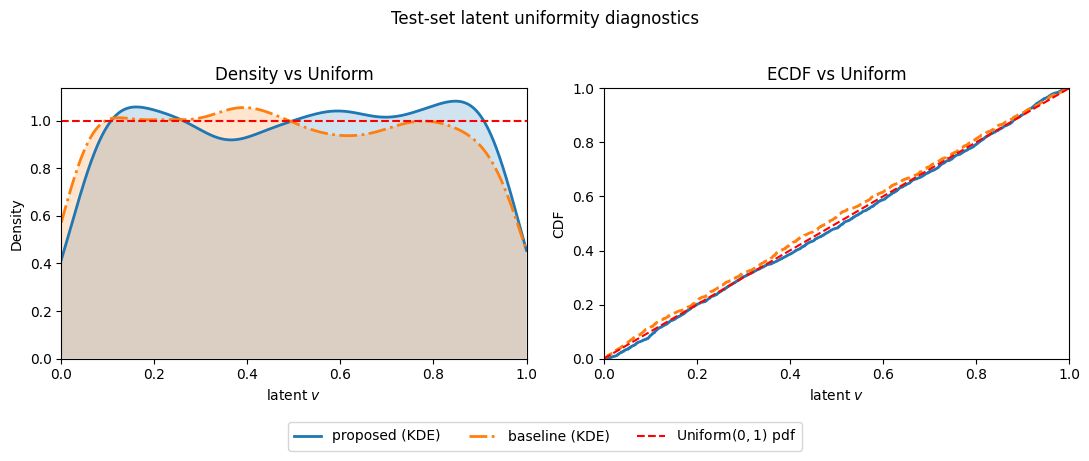

[Uniformity metrics on X_test]  (unbiased estimators may be slightly negative)
  MMD^2(proposed, Unif): +9.155273e-05
  MMD^2(baseline,  Unif): -1.013279e-04
  Energy(proposed, Unif): +1.497269e-04
  Energy(baseline,  Unif): -1.263320e-04
  KS(proposed vs Unif):   2.035298e-02
  KS(baseline vs Unif):   3.040494e-02


In [7]:

X_splits = {
    "X_train": x_np[tr_idx],
    "X_val":   x_np[va_idx],
    "X_test":  sample_x(
        n_samples=2000,
        dist_type="gaussian",
        params={"mean": np.array([0, 0]), "cov": np.diag([1, 1])},
        seed=1,
    ).astype(np.float32),
}


# -----------------------
# 1) compute latents once
# -----------------------
v_np  = encode_to_latent(model,     X_splits["X_test"], device)[:, 0]
v0_np = encode_to_latent(model_enc, X_splits["X_test"], device)[:, 0]

# clip for uniformity checks/plots if needed
# v_np  = np.clip(v_np,  0.0, 1.0)
# v0_np = np.clip(v0_np, 0.0, 1.0)

# -----------------------
# 2) make 2-panel plot
# -----------------------
grid = np.linspace(0, 1, 400)
kde_v  = gaussian_kde(v_np)(grid)
kde_v0 = gaussian_kde(v0_np)(grid)

def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x1, y1 = ecdf(v_np)
x2, y2 = ecdf(v0_np)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

# (a) KDE vs Uniform pdf
ax = axes[0]
ax.plot(grid, kde_v,  linewidth=2, label="proposed (KDE)")
ax.fill_between(grid, 0, kde_v, alpha=0.20)
ax.plot(grid, kde_v0, linewidth=2, linestyle="-.", label="baseline (KDE)")
ax.fill_between(grid, 0, kde_v0, alpha=0.20)
ax.axhline(1.0, linestyle="--", color="red", label=r"Uniform$(0,1)$ pdf")
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"latent $v$")
ax.set_ylabel("Density")
ax.set_title("Density vs Uniform")

# (b) ECDF vs Uniform CDF
ax = axes[1]
ax.plot(x1, y1, linewidth=2, label="proposed (ECDF)")
ax.plot(x2, y2, linewidth=2, linestyle="--", label="baseline (ECDF)")
ax.plot([0, 1], [0, 1], linestyle="--", color="red", label=r"Uniform$(0,1)$ CDF")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"latent $v$")
ax.set_ylabel("CDF")
ax.set_title("ECDF vs Uniform")

# one shared legend
handles, labels = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()
fig.legend(handles , labels , loc="lower center", ncol=3, frameon=True,bbox_to_anchor=(0.5, -0.1),)
# plt.legend()

fig.suptitle("Test-set latent uniformity diagnostics", y=1.02)
fig.tight_layout()
plt.show()

# -----------------------
# 3) print metrics
# -----------------------
# KS distance to Uniform(0,1): sup |F_n(t) - t|
def ks_to_uniform(x):
    x = np.sort(x)
    n = len(x)
    Fn = np.arange(1, n + 1) / n
    return float(np.max(np.abs(Fn - x)))

v  = torch.as_tensor(v_np,  device=device, dtype=torch.float32).view(-1, 1)
v0 = torch.as_tensor(v0_np, device=device, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    # shared reference uniforms for variance reduction
    ref_u = torch.rand_like(v)

    # shared sigma grid for fair comparison (use your median heuristic once)
    mmd_v  = mmd2_unif(v,  sigmas=None, ref_u=ref_u, use_median=False).item()
    mmd_v0 = mmd2_unif(v0, sigmas=None, ref_u=ref_u, use_median=False).item()

    # if you are on MPS, use the MPS-safe energy version (cdist-based) you defined earlier
    # ed_v  = energy_distance_unif_mps(v,  ref_u=ref_u).item()
    # ed_v0 = energy_distance_unif_mps(v0, ref_u=ref_u).item()

    # or CPU fallback (slower, but works)
    ed_v  = energy_distance_unif(v.cpu(),  ref_u.cpu()).item()
    ed_v0 = energy_distance_unif(v0.cpu(), ref_u.cpu()).item()

ks_v  = ks_to_uniform(v_np)
ks_v0 = ks_to_uniform(v0_np)

print("[Uniformity metrics on X_test]  (unbiased estimators may be slightly negative)")
print(f"  MMD^2(proposed, Unif): {mmd_v:+.6e}")
print(f"  MMD^2(baseline,  Unif): {mmd_v0:+.6e}")
print(f"  Energy(proposed, Unif): {ed_v:+.6e}")
print(f"  Energy(baseline,  Unif): {ed_v0:+.6e}")
print(f"  KS(proposed vs Unif):   {ks_v:.6e}")
print(f"  KS(baseline vs Unif):   {ks_v0:.6e}")


## Data Shift: Mean Perturbation

Let $\mathbb{P}_0 = \mathcal{N}(\mu, \Sigma)$, where
$
\mu=\begin{bmatrix}0\\0\end{bmatrix},
\Sigma=\begin{bmatrix}1 & 0\\ 0 & 1\end{bmatrix}.
$
In mean perturbation case, we consider $\mathbb{P}_1 = \mathcal{N}(\mu', \Sigma)$, with $\mu'=\begin{bmatrix}0\\0\end{bmatrix},$


In [ ]:
# for mu in each grid, compute how latent distribtuon diviate from unifrom, say under the null and under the alternative, 
# loop over mu:
#   for each mu, generate Xs: 
#       encode Xs to latent vs (two models)
#       compute vs divergence to uniform distribution
# plot divergence vs mu 

# setting 1 (under null): with mu=(0,0), set mu' = (0,delta), say delta = 0 to 1 with stepsize 0.1
# setting 2 (null to alternative): with mu=(0,0), set mu' = (delta,0), say delta = 0 to 1 with stepsize 0.1, after say delta = 0.5, it cross boundary, config change to unsafe
# setting 3 (under alternative): with mu=(0,0), set mu' = (-1,delta), say delta = 0 to 1 with stepsize 0.1, always alternative



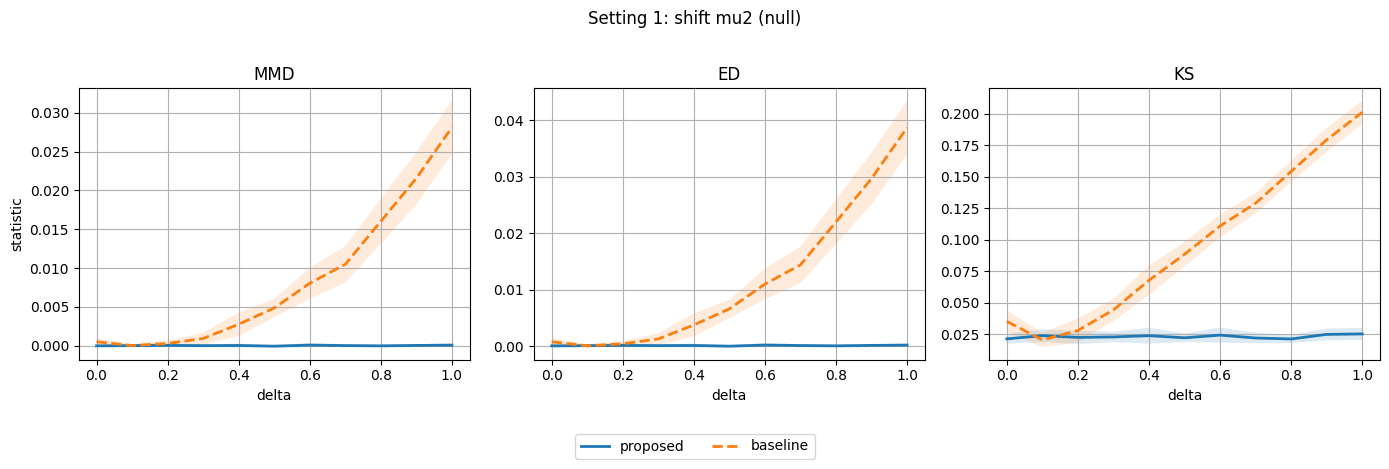

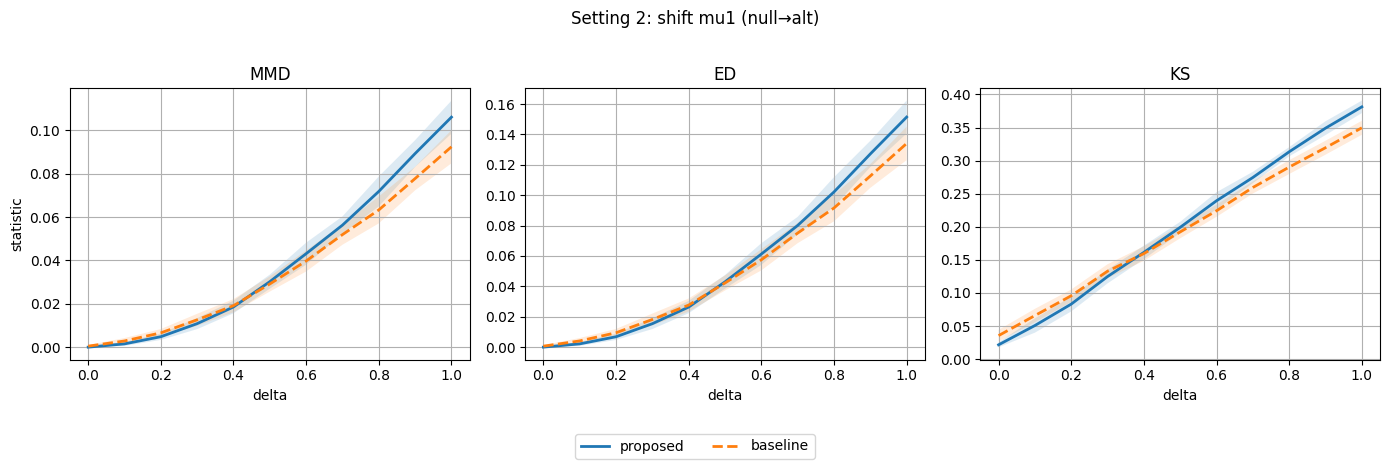

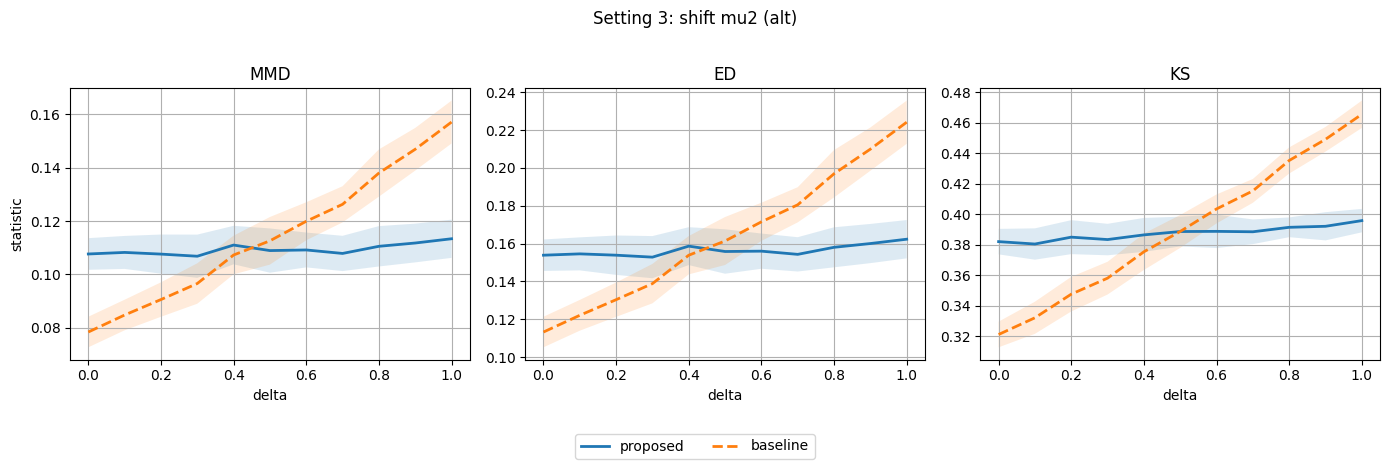

In [15]:
import sys, pathlib, numpy as np, torch, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, str(pathlib.Path("src").resolve()))
from data.sample_x import sample_x
from train.losses import mmd2_unif, energy_distance_unif

# ---------- helpers ----------
def ks_to_uniform(x):
    x = np.sort(x)
    n = len(x)
    Fn = np.arange(1, n + 1) / n
    return float(np.max(np.abs(Fn - x)))

@torch.no_grad()
def divergences(v_np, device, ref_u=None):
    v = torch.as_tensor(v_np, device=device, dtype=torch.float32).view(-1, 1)
    if ref_u is None:
        ref_u = torch.rand_like(v)
    mmd = mmd2_unif(v, sigmas=None, ref_u=ref_u, use_median=False).item()
    ed  = energy_distance_unif(v.cpu(), ref_u.cpu()).item()
    ks  = ks_to_uniform(v_np)
    return mmd, ed, ks

def sweep_direction(mu_base, direction, deltas, n_samples=2000, truncate_box=None, seed=1, n_reps=10):
    rows = []
    rng = np.random.default_rng(seed)
    for delta in deltas:
        mu = np.asarray(mu_base, float) + delta * np.asarray(direction, float)
        rep_stats = []
        for _ in range(n_reps):
            s = int(rng.integers(0, 2**32 - 1))
            X = sample_x(
                n_samples=n_samples,
                dist_type="gaussian",
                params={"mean": mu, "cov": np.diag([1., 1.])},
                seed=s,
                truncate_box=truncate_box,
            ).astype(np.float32)

            ref_u = torch.rand((n_samples, 1), device=device)
            v_prop = encode_to_latent(model,     X, device)[:, 0]
            v_base = encode_to_latent(model_enc, X, device)[:, 0]

            mmd_p, ed_p, ks_p = divergences(v_prop, device, ref_u=ref_u)
            mmd_b, ed_b, ks_b = divergences(v_base, device, ref_u=ref_u)
            rep_stats.append((mmd_p, mmd_b, ed_p, ed_b, ks_p, ks_b))

        rep_stats = np.array(rep_stats)
        rows.append({
            "delta": delta,
            "mu1": mu[0], "mu2": mu[1],
            "mmd_prop": rep_stats[:,0].mean(), "mmd_base": rep_stats[:,1].mean(),
            "ed_prop":  rep_stats[:,2].mean(), "ed_base":  rep_stats[:,3].mean(),
            "ks_prop":  rep_stats[:,4].mean(), "ks_base":  rep_stats[:,5].mean(),
            "mmd_prop_std": rep_stats[:,0].std(), "mmd_base_std": rep_stats[:,1].std(),
            "ed_prop_std":  rep_stats[:,2].std(), "ed_base_std":  rep_stats[:,3].std(),
            "ks_prop_std":  rep_stats[:,4].std(), "ks_base_std":  rep_stats[:,5].std(),
        })
    return pd.DataFrame(rows)

def plot_metrics_row(df, setting_title):
    metrics = ["mmd", "ed", "ks"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(df["delta"], df[f"{metric}_prop"], lw=2, label="proposed")
        ax.plot(df["delta"], df[f"{metric}_base"], lw=2, ls="--", label="baseline")
        ax.fill_between(df["delta"],
                        df[f"{metric}_prop"] - df[f"{metric}_prop_std"],
                        df[f"{metric}_prop"] + df[f"{metric}_prop_std"],
                        alpha=0.15)
        ax.fill_between(df["delta"],
                        df[f"{metric}_base"] - df[f"{metric}_base_std"],
                        df[f"{metric}_base"] + df[f"{metric}_base_std"],
                        alpha=0.15)
        ax.set_xlabel("delta"); ax.set_title(metric.upper()); ax.grid(True)
    axes[0].set_ylabel("statistic")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.12))
    fig.suptitle(setting_title, y=1.02)
    fig.tight_layout()
    plt.show()

@torch.no_grad()
def stats_vs_unif(v_np):
    v = torch.as_tensor(v_np, device=device, dtype=torch.float32).view(-1, 1)
    ref_u = torch.rand_like(v)
    mmd = mmd2_unif(v, sigmas=None, ref_u=ref_u, use_median=False).item()
    ed  = energy_distance_unif(v.cpu(), ref_u.cpu()).item()
    ks  = ks_to_uniform(v_np)
    return mmd, ed, ks

# ---------- run sweeps with repetition ----------
# deltas = np.round(np.arange(0.0, 1.01, 0.1), 2)
deltas = np.linspace(0,1,11)
truncate_box = (-3.0, 3.0)
n_reps = 30

# Setting 1: shift mu2 under null
df1 = sweep_direction(mu_base=(0,0), direction=(0,1), deltas=deltas, truncate_box=truncate_box, n_reps=n_reps)
plot_metrics_row(df1, "Setting 1: shift mu2 (null)")

# Setting 2: shift mu1 null→alt, cross decision boundary at 0.7
df2 = sweep_direction(mu_base=(0,0), direction=(1,0), deltas=deltas, truncate_box=truncate_box, n_reps=n_reps)
plot_metrics_row(df2, "Setting 2: shift mu1 (null→alt)")

# Setting 3: shift mu2 from mu1=-1 (alt)
df3 = sweep_direction(mu_base=(-1,0), direction=(0,1), deltas=deltas, truncate_box=truncate_box, n_reps=n_reps)
plot_metrics_row(df3, "Setting 3: shift mu2 (alt)")

# Inspect aggregated stats if needed
# display(df1.head(), df2.head(), df3.head())



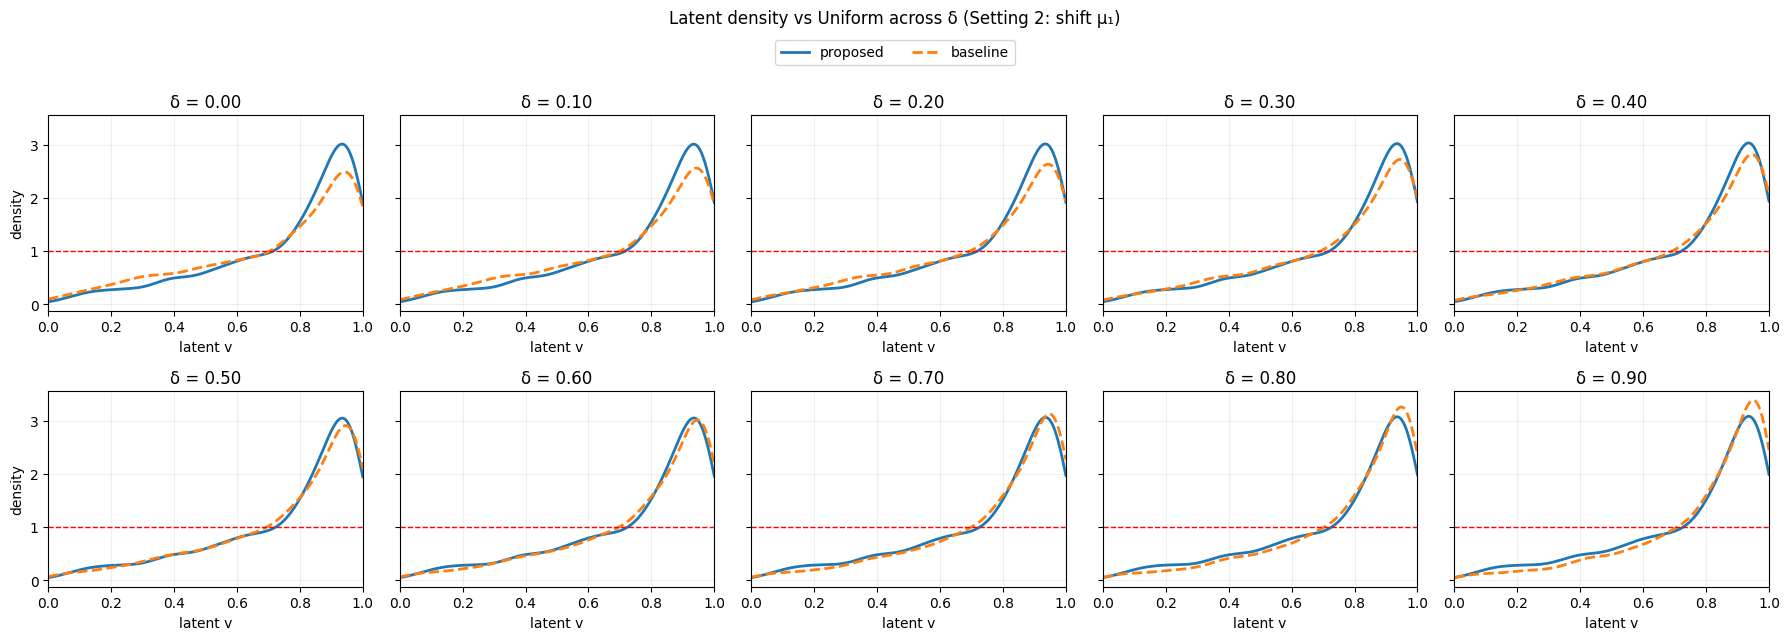

In [20]:
import sys, pathlib, numpy as np, torch, matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
sys.path.insert(0, str(pathlib.Path("src").resolve()))
from data.sample_x import sample_x
from train.losses import mmd2_unif, energy_distance_unif

deltas = np.linspace(0, 1, 11)  # 10 deltas


# ------------ run sweep & plot 2x5 ------------
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=True)
grid = np.linspace(0, 1, 400)

for ax, delta in zip(axes.ravel(), deltas):
    mu = np.array([-1, delta], dtype=float)
    X = sample_x(
        n_samples=n_samples,
        dist_type="gaussian",
        params={"mean": mu, "cov": cov},
        seed=1,
        truncate_box=truncate_box,
    ).astype(np.float32)

    v_prop = encode_to_latent(model,     X, device)[:, 0]
    v_base = encode_to_latent(model_enc, X, device)[:, 0]

    kde_p  = gaussian_kde(v_prop)(grid)
    kde_b  = gaussian_kde(v_base)(grid)

    ax.plot(grid, kde_p, lw=2, label="proposed")
    ax.plot(grid, kde_b, lw=2, ls="--", label="baseline")
    ax.axhline(1.0, ls="--", c="red", lw=1)
    ax.set_title(f"δ = {delta:.2f}")
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.2)
    if ax in axes[:,0]:
        ax.set_ylabel("density")
    ax.set_xlabel("latent v")

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Latent density vs Uniform across δ (Setting 2: shift μ₁)", y=1.06)
fig.tight_layout()
plt.show()


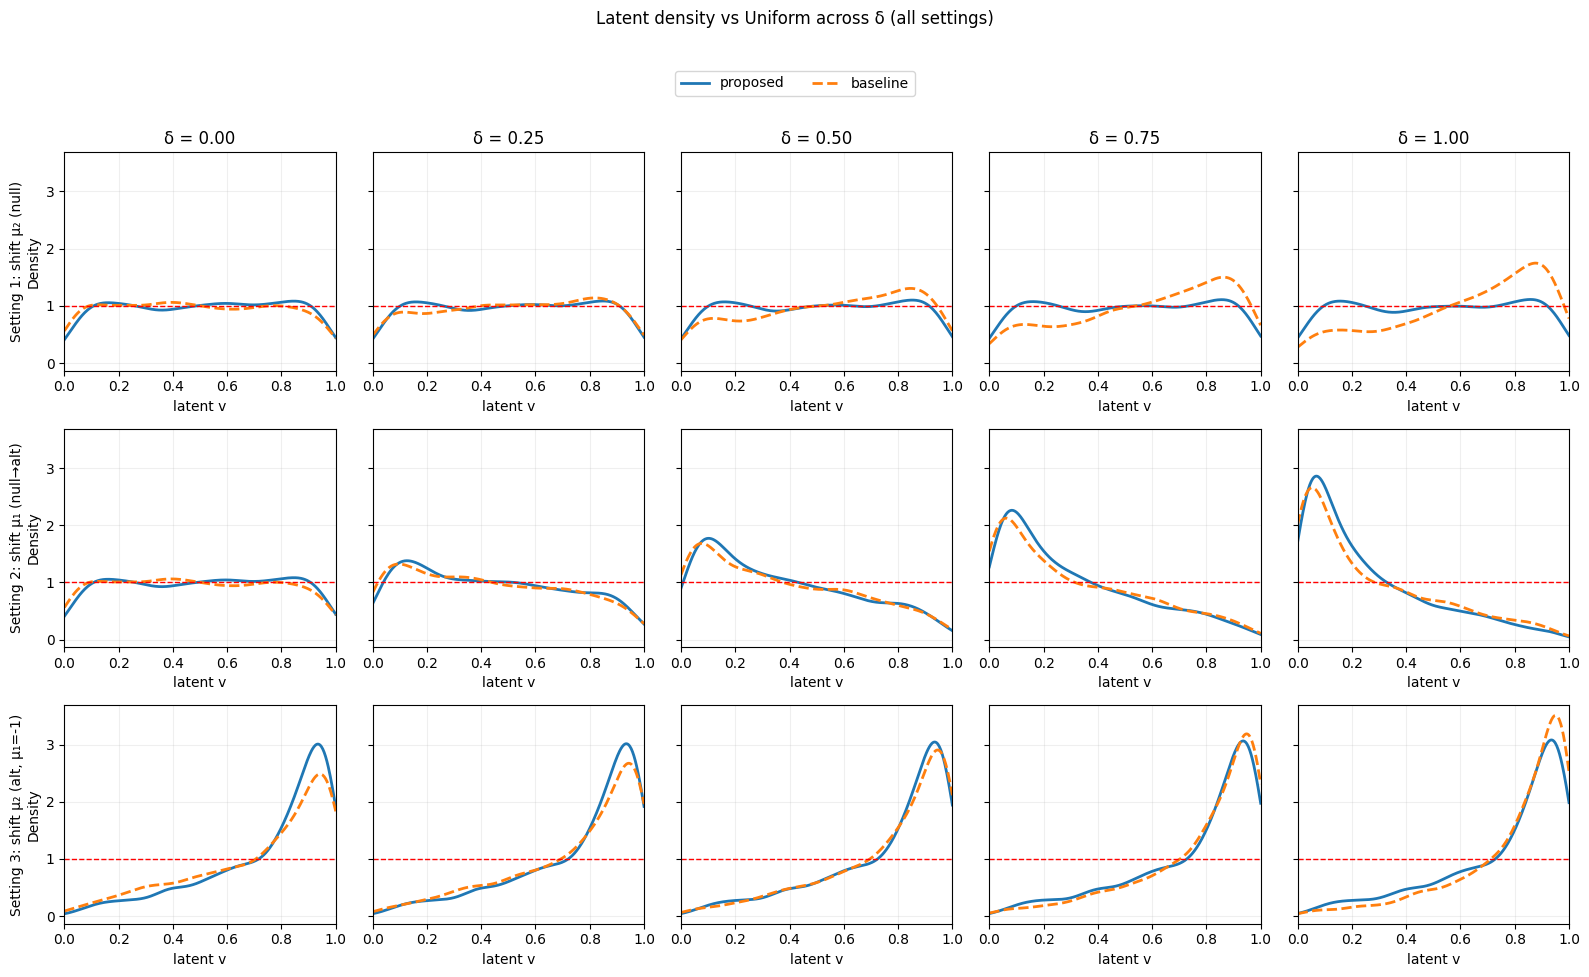

In [10]:
import sys, pathlib, numpy as np, torch, matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
sys.path.insert(0, str(pathlib.Path("src").resolve()))
from data.sample_x import sample_x
from train.losses import mmd2_unif, energy_distance_unif

deltas = [0.00, 0.25, 0.50, 0.75, 1.00]
truncate_box = (-3.0, 3.0)
n_samples = 2000
cov = np.diag([1., 1.])

def ks_to_uniform(x):
    x = np.sort(x)
    n = len(x)
    Fn = np.arange(1, n + 1) / n
    return float(np.max(np.abs(Fn - x)))

@torch.no_grad()
def stats_vs_unif(v_np):
    v = torch.as_tensor(v_np, device=device, dtype=torch.float32).view(-1, 1)
    ref_u = torch.rand_like(v)
    mmd = mmd2_unif(v, sigmas=None, ref_u=ref_u, use_median=False).item()
    ed  = energy_distance_unif(v.cpu(), ref_u.cpu()).item()
    ks  = ks_to_uniform(v_np)
    return mmd, ed, ks

settings = [
    ("Setting 1: shift μ₂ (null)",      np.array([0.0, 0.0]), np.array([0.0, 1.0])),
    ("Setting 2: shift μ₁ (null→alt)",  np.array([0.0, 0.0]), np.array([1.0, 0.0])),
    ("Setting 3: shift μ₂ (alt, μ₁=-1)",np.array([-1.0, 0.0]),np.array([0.0, 1.0])),
]

fig, axes = plt.subplots(len(settings), len(deltas), figsize=(16, 9), sharey=True)
grid = np.linspace(0, 1, 400)

for row, (title, mu_base, direction) in enumerate(settings):
    # plotting
    for ax, delta in zip(axes[row], deltas):
        mu = mu_base + delta * direction
        X = sample_x(
            n_samples=n_samples,
            dist_type="gaussian",
            params={"mean": mu, "cov": cov},
            seed=1,
            truncate_box=truncate_box,
        ).astype(np.float32)

        v_prop = encode_to_latent(model,     X, device)[:, 0]
        v_base = encode_to_latent(model_enc, X, device)[:, 0]

        kde_p  = gaussian_kde(v_prop)(grid)
        kde_b  = gaussian_kde(v_base)(grid)

        ax.plot(grid, kde_p, lw=2, label="proposed")
        ax.plot(grid, kde_b, lw=2, ls="--", label="baseline")
        ax.axhline(1.0, ls="--", c="red", lw=1)
        ax.set_title(f"δ = {delta:.2f}" if row == 0 else "")
        ax.set_xlim(0, 1); ax.grid(True, alpha=0.2)
        if ax is axes[row][0]:
            ax.set_ylabel(f"{title}\nDensity")
        ax.set_xlabel("latent v")

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Latent density vs Uniform across δ (all settings)", y=1.08)
fig.tight_layout()
plt.show()

# # ------------ print metrics per δ, per setting ------------
# for title, mu_base, direction in settings:
#     print(f"\n{title}")
#     print("delta | MMD^2 prop | MMD^2 base | Energy prop | Energy base | KS prop | KS base")
#     rows = []
#     for delta in deltas:
#         mu = mu_base + delta * direction
#         X = sample_x(
#             n_samples=n_samples,
#             dist_type="gaussian",
#             params={"mean": mu, "cov": cov},
#             seed=2,  # different seed from plot
#             truncate_box=truncate_box,
#         ).astype(np.float32)
#         v_prop = encode_to_latent(model,     X, device)[:, 0]
#         v_base = encode_to_latent(model_enc, X, device)[:, 0]
#         mmd_p, ed_p, ks_p = stats_vs_unif(v_prop)
#         mmd_b, ed_b, ks_b = stats_vs_unif(v_base)
#         rows.append((delta, mmd_p, mmd_b, ed_p, ed_b, ks_p, ks_b))
#         print(f"{delta:4.2f} | {mmd_p:+.3e} | {mmd_b:+.3e} | {ed_p:+.3e} | {ed_b:+.3e} | {ks_p:.3e} | {ks_b:.3e}")
